In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set(style="whitegrid",palette="muted",font_scale=1.2)

In [ ]:
bio_df = pd.read_csv("biometric_master.csv")
demo_df = pd.read_csv("demographic_master.csv")
enrol_df = pd.read_csv("enrolment_master.csv")

bio_df.columns = bio_df.columns.str.strip().str.lower()
demo_df.columns = demo_df.columns.str.strip().str.lower()
enrol_df.columns = enrol_df.columns.str.strip().str.lower()

/tmp/ipython-input-1274146563.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  bio_df = pd.read_csv("biometric_master.csv")


In [ ]:
enrol_demo = pd.merge(enrol_df, demo_df,
                      on=['date','state','district','pincode'],
                      how='outer',
                      suffixes=('_enrol','_demo'))

full_df = pd.merge(enrol_demo, bio_df,
                   on=['date','state','district','pincode'],
                   how='outer')

full_df = full_df.fillna(0)

print("Final merged dataset shape:", full_df.shape)
print(full_df.head())


Final merged dataset shape: (14695923, 13)
         date                        state  district  pincode  age_0_5  \
0  2025-01-03    Andaman & Nicobar Islands  Andamans   744101      0.0   
1  2025-01-03  Andaman and Nicobar Islands   Nicobar   744301      0.0   
2  2025-01-03  Andaman and Nicobar Islands   Nicobar   744302      0.0   
3  2025-01-03  Andaman and Nicobar Islands   Nicobar   744303      0.0   
4  2025-01-03  Andaman and Nicobar Islands   Nicobar   744304      0.0   

   age_5_17  age_18_greater  ratio_adult_youth  demo_age_5_17  demo_age_17_  \
0       0.0             0.0                0.0            0.0           0.0   
1       0.0             0.0                0.0            0.0           0.0   
2       0.0             0.0                0.0            0.0           0.0   
3       0.0             0.0                0.0            0.0           0.0   
4       0.0             0.0                0.0            0.0           0.0   

   ratio_17plus  bio_age_5_17  bio_ag

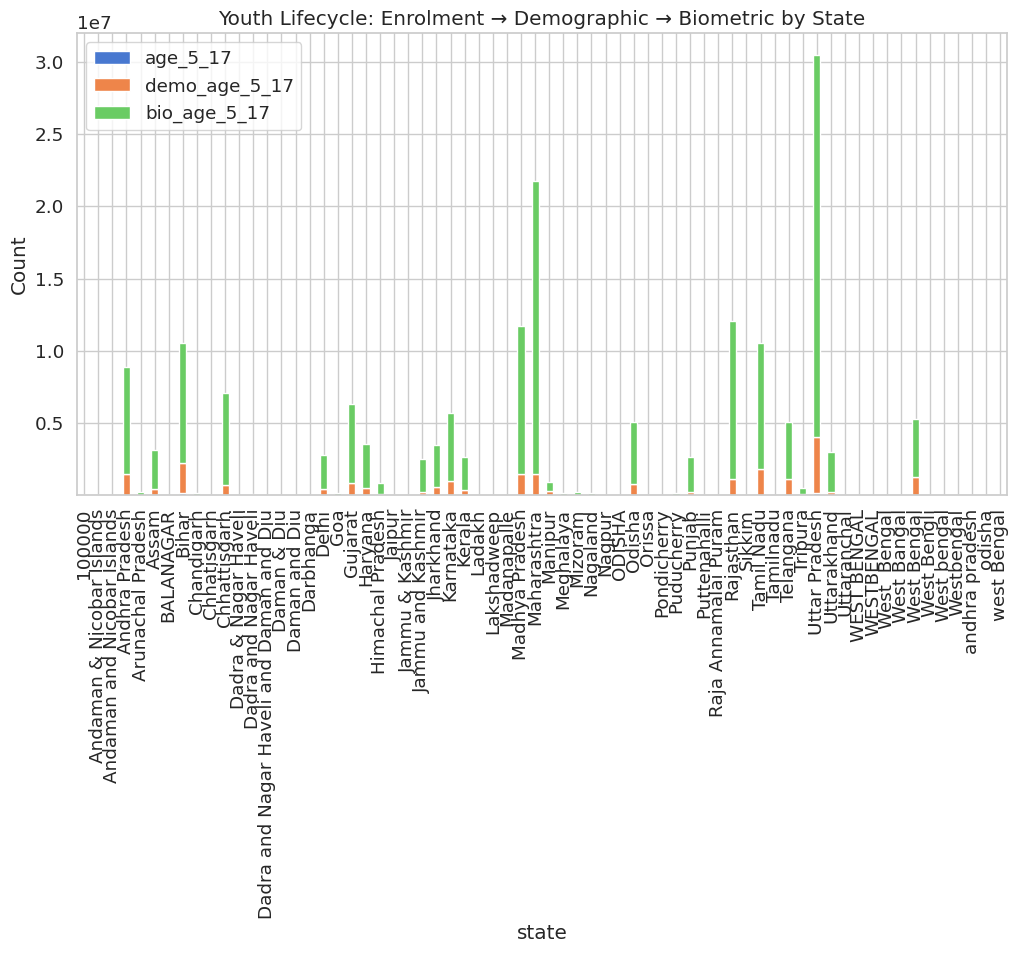

In [ ]:
state_lifecycle = full_df.groupby('state')[['age_0_5','age_5_17','age_18_greater',
                                            'demo_age_5_17','demo_age_17_',
                                            'bio_age_5_17','bio_age_17_']].sum().reset_index()

import matplotlib.pyplot as plt

state_lifecycle.set_index('state')[['age_5_17','demo_age_5_17','bio_age_5_17']].plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Youth Lifecycle: Enrolment → Demographic → Biometric by State")
plt.ylabel("Count")
plt.show()

In [ ]:
corr = full_df[['age_18_greater','demo_age_17_','bio_age_17_']].corr()
print("Correlation between adult enrolment, demographic updates, and biometric updates:")
print(corr)

Correlation between adult enrolment, demographic updates, and biometric updates:
                age_18_greater  demo_age_17_  bio_age_17_
age_18_greater        1.000000      0.000158    -0.001865
demo_age_17_          0.000158      1.000000     0.353626
bio_age_17_          -0.001865      0.353626     1.000000


In [ ]:
anomalies_lifecycle = full_df[(full_df['age_18_greater'] > 5) & (full_df['bio_age_17_'] < 2)]
print("Lifecycle anomalies (adult enrolment high, biometric low):")
print(anomalies_lifecycle[['state','district','pincode','age_18_greater','bio_age_17_']].head(10))

Lifecycle anomalies (adult enrolment high, biometric low):
                  state            district  pincode  age_18_greater  \
1302665           Assam              Kamrup   781380             9.0   
1302666           Assam              Kamrup   781380             9.0   
1303025           Assam            Sibsagar   785697             6.0   
1305787         Gujarat        Chhotaudepur   391135             6.0   
1305882         Gujarat         Gir Somnath   362720            15.0   
1312274  Madhya Pradesh              Morena   476444             9.0   
1314913       Meghalaya  East Jaintia Hills   793200            15.0   
1314914       Meghalaya  East Jaintia Hills   793200            15.0   
1314924       Meghalaya    East Khasi Hills   793009            13.0   
1314925       Meghalaya    East Khasi Hills   793010             6.0   

         bio_age_17_  
1302665          1.0  
1302666          1.0  
1303025          1.0  
1305787          0.0  
1305882          0.0  
1312274   

In [ ]:
# Insight Extraction

# Totals
total_enrol = full_df[['age_0_5','age_5_17','age_18_greater']].sum().sum()
total_demo = full_df[['demo_age_5_17','demo_age_17_']].sum().sum()
total_bio = full_df[['bio_age_5_17','bio_age_17_']].sum().sum()

# State leaders
top_youth_enrol_state = full_df.groupby('state')['age_5_17'].sum().idxmax()
top_adult_enrol_state = full_df.groupby('state')['age_18_greater'].sum().idxmax()
top_demo_state = full_df.groupby('state')['demo_age_17_'].sum().idxmax()
top_bio_state = full_df.groupby('state')['bio_age_17_'].sum().idxmax()

# Lifecycle completeness
full_df['has_enrol'] = (full_df[['age_0_5','age_5_17','age_18_greater']].sum(axis=1) > 0).astype(int)
full_df['has_demo'] = (full_df[['demo_age_5_17','demo_age_17_']].sum(axis=1) > 0).astype(int)
full_df['has_bio'] = (full_df[['bio_age_5_17','bio_age_17_']].sum(axis=1) > 0).astype(int)
full_df['lifecycle_complete'] = (full_df['has_enrol'] & full_df['has_demo'] & full_df['has_bio'])

complete_districts = full_df['lifecycle_complete'].sum()
total_districts = full_df.shape[0]

print(" Key Lifecycle Insights:")
print(f"- Total enrolments: {total_enrol}")
print(f"- Total demographic updates: {total_demo}")
print(f"- Total biometric updates: {total_bio}")
print(f"- {top_youth_enrol_state} leads in youth enrolments.")
print(f"- {top_adult_enrol_state} leads in adult enrolments.")
print(f"- {top_demo_state} leads in adult demographic updates.")
print(f"- {top_bio_state} leads in adult biometric updates.")
print(f"- Lifecycle completeness: {complete_districts}/{total_districts} districts have all three stages recorded.")
print("- Districts missing one or more stages highlight operational gaps in Aadhaar lifecycle coverage.")


 Key Lifecycle Insights:
- Total enrolments: 2396893.0
- Total demographic updates: 237751578.0
- Total biometric updates: 275893180.0
- Uttar Pradesh leads in youth enrolments.
- Assam leads in adult enrolments.
- Uttar Pradesh leads in adult demographic updates.
- Maharashtra leads in adult biometric updates.
- Lifecycle completeness: 96512/14695923 districts have all three stages recorded.
- Districts missing one or more stages highlight operational gaps in Aadhaar lifecycle coverage.


In [ ]:

# Funnel Chart (Lifecycle Drop-offs)
funnel_data = pd.DataFrame({
    'Stage': ['Enrolment','Demographic Updates','Biometric Updates'],
    'Count': [total_enrol, total_demo, total_bio]
})

fig = px.funnel(funnel_data, x='Count', y='Stage',
                title="Aadhaar Lifecycle Funnel: Enrolment → Demographic → Biometric")
fig.show()